# OpenVSP Aerodynamic Analysis and Optimization

**Project workflow:** bundled OpenVSP + local `interpreter/` + `libs/` + `.venv/` + notebook-first usage  
**Bundled solver:** `OpenVSP-3.48.2-win64` already included in this repository  
**Important Python note:** this bundled OpenVSP build links against `python313.dll`, so Python 3.13 is required for the local repository runtime.

---

## Overview

This notebook is the easiest entry point for the final user.

What it does:
1. Bootstraps the local project environment when needed.
2. Verifies that the embedded OpenVSP runtime is usable.
3. Loads the `.vsp3` aircraft model and explains the key geometry.
4. Shows reference quantities and mass properties before the aerodynamic run.
5. Runs a baseline VSPAERO sweep and exposes convergence and stability diagnostics.
6. Continues with sweep and optimization workflows exactly as before.

If you are a less experienced user, run the first two sections in order without skipping cells.


---
## Section 0 - Bootstrap

This section is optional, but recommended the first time you open the notebook.

- If the local runtime folders are missing, the next cell runs `run_project.bat setup` for you.
- Setup prepares `interpreter/`, installs packages into `libs/`, and then creates `.venv/`.
- If the environment already exists, the cell simply tells you whether this notebook is already using the correct interpreter.
- If setup fails, the cell prints the launcher output so you can see the real reason immediately.
- After the first setup, select the kernel named **OpenVSP Controller (.venv)** and rerun the notebook from the top.


In [1]:
import os
import subprocess
import sys
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "run_project.bat").exists() and (candidate / "scripts" / "run_project.ps1").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
RUN_SCRIPT = REPO_ROOT / "run_project.bat"
EXPECTED_LOCAL_PYTHON = REPO_ROOT / "interpreter" / "python.exe"
EXPECTED_LIBS_DIR = REPO_ROOT / "libs"
EXPECTED_VENV_PYTHON = REPO_ROOT / ".venv" / "Scripts" / "python.exe"

print(f"Current interpreter   : {sys.executable}")
print(f"Expected local Python : {EXPECTED_LOCAL_PYTHON}")
print(f"Expected libs path    : {EXPECTED_LIBS_DIR}")
print(f"Expected .venv path   : {EXPECTED_VENV_PYTHON}")

running_in_project_runtime = (
    (EXPECTED_VENV_PYTHON.exists() and Path(sys.executable).resolve() == EXPECTED_VENV_PYTHON.resolve())
    or (EXPECTED_LOCAL_PYTHON.exists() and Path(sys.executable).resolve() == EXPECTED_LOCAL_PYTHON.resolve())
)

if running_in_project_runtime:
    print("Notebook is already using a repository-local Python runtime.")
elif os.name == "nt" and RUN_SCRIPT.exists():
    print("Repository-local runtime not active yet. Running setup now...")
    result = subprocess.run(
        ["cmd", "/c", str(RUN_SCRIPT), "setup"],
        cwd=str(REPO_ROOT),
        text=True,
        capture_output=True,
    )
    if result.stdout.strip():
        print(result.stdout.strip())
    if result.returncode == 0:
        print("\nSetup completed.")
        print("Repository-local folders ready: interpreter/, libs/, .venv/.")
        print("Next step: switch the notebook kernel to 'OpenVSP Controller (.venv)' and rerun from the top.")
    else:
        if result.stderr.strip():
            print(result.stderr.strip())
        print("\nAutomatic setup failed.")
        print("Read the launcher output above for the exact cause.")
        combined_output = f"{result.stdout}\n{result.stderr}"
        if "Python 3.13 was not found" in combined_output:
            print("This repository ships an OpenVSP build compiled for Python 3.13.")
            print("Install Python 3.13 once, then rerun this cell so the project can copy that runtime locally.")
        raise RuntimeError("Bootstrap failed. See the notebook output above.")
else:
    print("Automatic bootstrap is available only on Windows.")
    print(f"Run manually: {RUN_SCRIPT} setup")


Current interpreter   : C:\Users\UtenteLocale\Desktop\OpenVspController-main\.venv\Scripts\python.exe
Expected local Python : C:\Users\UtenteLocale\Desktop\OpenVspController-main\interpreter\python.exe
Expected libs path    : C:\Users\UtenteLocale\Desktop\OpenVspController-main\libs
Expected .venv path   : C:\Users\UtenteLocale\Desktop\OpenVspController-main\.venv\Scripts\python.exe
Notebook is already using a repository-local Python runtime.


---
## Section 1 - Configuration

Edit only the values in the next code cell. The rest of the notebook reads from those variables.


In [2]:
from pathlib import Path

MODEL_PATH = REPO_ROOT / "models" / "VESPA2.vsp3"  # change this to your model if needed
EXPORT_DIR = REPO_ROOT / "exports"

# Aerodynamic parameters
ALPHA_START = -5.0
ALPHA_END = 20.0
ALPHA_NPTS = 7
MACH = 0.2
RE_CREF = 1e6

# VSPAERO parameters
WAKE_ITER = 5
USE_MASSPROP_CG = True

# Optimization parameters
N_BAYESIAN_TRIALS = 60
RANDOM_SEED = 42

print(f"Model path : {MODEL_PATH.resolve()}")
print(f"Export dir : {EXPORT_DIR.resolve()}")
print(f"Use MassProp CG before VSPAERO: {USE_MASSPROP_CG}")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)


Model path : C:\Users\UtenteLocale\Desktop\OpenVspController-main\models\VESPA2.vsp3
Export dir : C:\Users\UtenteLocale\Desktop\OpenVspController-main\exports
Use MassProp CG before VSPAERO: True


---
## Section 2 - Environment verification

Before touching the model, we verify that:
- the repository-local runtime folders are present and readable;
- the embedded OpenVSP copy included in the repository is visible to Python;
- the active environment matches the required Python ABI for that OpenVSP build;
- the `.vsp3` file exists and looks valid.

If anything fails here, stop and fix it before proceeding.


In [3]:
import sys
sys.path.insert(0, str(REPO_ROOT))

from vspopt.utils import check_openvsp_version, check_vsp3_integrity, setup_logging

setup_logging("INFO")

ok_vsp, msg_vsp = check_openvsp_version((3, 48, 0))
ok_model, msg_model = check_vsp3_integrity(MODEL_PATH)

print(f"[{'OK' if ok_vsp else 'FAIL'}] OpenVSP : {msg_vsp}")
print(f"[{'OK' if ok_model else 'FAIL'}] Model   : {msg_model}")

#if not ok_vsp or not ok_model:
#    raise SystemExit("Environment check failed. Fix the reported issue before proceeding.")

print("\nEnvironment check passed.")


[OK] OpenVSP : OpenVSP 3.48.2 (from bundled folder name (OpenVSP-3.48.2-win64)) meets requirement >=3.48.0
[OK] Model   : OK (size=1169.5 KB)

Environment check passed.


---
## Section 2 — Aircraft model loading

### Physical background — what is in a .vsp3 file?

A `.vsp3` file is an XML document that stores the full parametric geometry of the aircraft.
Each geometry *component* (wing, fuselage, horizontal tail…) is represented by a tree of
**parameters** grouped by function.  The key parameter groups for a lifting surface are:

| Group | Typical parameters |
|---|---|
| `WingGeom` | `Span`, `Aspect`, `TotalArea` |
| `XSec_N`   | `Root_Chord`, `Tip_Chord`, `Sweep`, `Dihedral`, `Twist` |
| `XSecCurve` | Airfoil shape (NACA 4/5, Bezier, …) |

The `AircraftModel` class reads these parameters into Python objects so that you can write
`model.wing.span` instead of `vsp.GetParmVal(vsp.GetParm(wing_id, 'Span', 'WingGeom'))`.

In [4]:
from IPython.display import display
import pandas as pd

from vspopt import AircraftModel

model = AircraftModel(MODEL_PATH).load()
model.setup_aero_set()
print(model.summary())

print("Reference quantities currently stored in the model:")
display(pd.Series(model.reference_quantities(), name="value").to_frame())

mass_props = model.mass_properties()
print("Mass properties from OpenVSP MassProp:")
display(mass_props.to_series().rename("value").to_frame())


00:38:13 [INFO   ] vspopt.wrapper — Loading VSP model: C:\Users\UtenteLocale\Desktop\OpenVspController-main\models\VESPA2.vsp3
00:38:15 [WARNING] vspopt.wrapper — Duplicate geometry name 'SBEC' detected. Renaming to 'SBEC_2' in Python cache.
00:38:15 [INFO   ] vspopt.wrapper — Model loaded: 39 geometry components found (39 in VSP, 39 unique in cache).
TEST FAILED: Could not find parameter 'Max_Diameter'. Using default: 99.0
TEST RESULT: Theory confirmed! OpenVSP does not give us the global diameter.
Restoring the forced diameter to 0.16 to continue the calculation.
00:38:15 [INFO   ] vspopt.model — AircraftModel loaded: 39 components (WingGeom, Batteria_1, Batteria_2, Serbatoio, FuselageGeom, Motore ant dx, Motore ant sx, Motore post sx, Motore post dx, Pompa, Elettrovalvola, CubeOrange, ESC1, ESC2, ESC3, ESC4, TD SR18 Receiver, RFD 900X Telemetry , HingeAntDx, PropAntDx, HingeAntSx, PropAntSx, PropPostSx, PropPostDx, CubeID, FrSky Archer, Tensore di corrente, Mauch021 BEC FC, SBEC, SB

,value
Sref,0.98
bref,2.80
cref,0.35


00:38:22 [INFO   ] vspopt.wrapper — MassProp completed: extracted 41 result fields (including Total_CG).
Mass properties from OpenVSP MassProp:


,value
mass [kg],10.397021
xcg [m],0.508502
ycg [m],-0.000082
zcg [m],0.819512
Ixx [kg m^2],0.583331
Iyy [kg m^2],1.040037
Izz [kg m^2],1.322124
Ixy [kg m^2],-0.000467
Ixz [kg m^2],0.091673
Iyz [kg m^2],-0.000058


In [5]:
# Display geometry table for the main components

df_geom = model.geometry_table()
print("Geometry summary:")
display(df_geom)


Geometry summary:


,span [m],area [m²],aspect_ratio [-],root_chord [m],tip_chord [m],taper_ratio [-],mac [m],sweep_le [deg],dihedral [deg],twist_tip [deg],role,length [m],max_diameter [m],fineness_ratio [-]
WingGeom,1.4,0.98,4.0,0.35,0.35,1.0,0.35,0.0,0.0,0.0,wing,—,—,—
FuselageGeom,—,—,—,—,—,—,—,—,—,—,fuselage,1.4,0.3,4.666667
Vtail,0.55,0.275,2.2,0.25,0.25,1.0,0.25,0.0,35.0,0.0,vtp,—,—,—


In [6]:
# Inspect ALL parameters of the main wing
# This is useful when you need the exact group/param names for the wrapper.

if model.wing:
    wing_params = model.wrapper.get_all_params(model.wing.name)
    df_wing_params = pd.Series(wing_params, name="value").to_frame()
    df_wing_params.index.name = "group/param"
    print(f"All parameters for component '{model.wing.name}':")
    display(df_wing_params)


All parameters for component 'WingGeom':


,value
group/param,
XForm/Abs_Or_Relitive_flag,1.00
XForm/Last_Scale,1.00
XForm/Origin,0.00
XForm/Scale,1.00
XForm/X_Location,0.46
...,...
Chevron/W01_End_Guide,5.00
Chevron/W01_Mode,0.00
Chevron/W01_Start,0.00


---
## Section 3 — Baseline VSPAERO polar sweep

### Physical background — Vortex Lattice Method

VSPAERO implements the **Vortex Lattice Method (VLM)**, a panel method based on
potential flow theory.  The lifting surfaces are discretised into a grid of
horseshoe vortices.  Each vortex induces a velocity according to the **Biot–Savart law**:

$$\mathbf{u}(\mathbf{r}) = \frac{\Gamma}{4\pi} \int_C \frac{d\boldsymbol{\ell} \times \hat{\mathbf{r}}}{|\mathbf{r}|^2}$$

The vortex strengths $\Gamma_i$ are found by satisfying the **no-penetration boundary
condition** (zero normal velocity at each control point), yielding a linear system:

$$[A]\{\Gamma\} = \{RHS\}$$

Once solved, the aerodynamic forces follow from the **Kutta–Joukowski theorem**:
$dL = \rho V_\infty \Gamma \, ds$

The drag is split into:
- **Induced drag** $C_{D,i} = \frac{C_L^2}{\pi AR \, e}$ — arises from the finite wing's
  tip vortices.  $e$ is the Oswald efficiency factor (1 for an elliptical distribution).
- **Profile drag** $C_{D,0}$ — skin friction + pressure drag; estimated empirically.

**Expected behaviour:**
- $C_L$ is approximately linear in $\alpha$ (slope $\approx 2\pi$ per radian = 0.11/°).
- $C_D$ is parabolic in $C_L$ (drag polar: $C_D = C_{D0} + C_L^2/(\pi AR e)$).
- $L/D$ has a clear maximum at the design operating point.

In [7]:
import numpy as np

sweep_kwargs = dict(
    alpha_start=ALPHA_START,
    alpha_end=ALPHA_END,
    alpha_npts=ALPHA_NPTS,
    mach=MACH,
    re_cref=RE_CREF,
    wake_iter=WAKE_ITER,
    use_massprop_cg=USE_MASSPROP_CG,
)

print("Running VSPAERO baseline sweep...")
baseline = model.wrapper.run_vspaero_sweep(**sweep_kwargs)
print(baseline)

issues = baseline.validate()
if issues:
    print("Validation warnings:")
    for warning in issues:
        print(f"  - {warning}")
else:
    print("Validation: all checks passed.")

if baseline.convergence:
    print(
        f"Convergence: {'OK' if baseline.converged else 'CHECK'} | "
        f"iterations = {baseline.convergence.get('n_iter', 0)} | "
        f"reason = {baseline.convergence.get('reason', 'n/a')}"
    )

if np.isfinite(baseline.static_margin):
    print(
        f"Static margin = {baseline.static_margin:.4f} | "
        f"X_np = {baseline.neutral_point_x:.4f} m"
    )


Running VSPAERO baseline sweep...
00:38:26 [INFO   ] vspopt.wrapper — Running VSPAEROSweep: alpha=[-5.0 deg, 20.0 deg] x 7 pts, M=0.20, Re=1.00e+06
00:38:26 [INFO   ] vspopt.wrapper — Computing VSPAERO Geometry (DegenGeom)...
00:38:33 [INFO   ] vspopt.wrapper — MassProp completed: extracted 41 result fields (including Total_CG).
[VSPAERO DEBUG] 'Alpha' -> Found directly.
[VSPAERO DEBUG] 'CL   ' -> Found directly.
[VSPAERO DEBUG] 'CDtot' -> Found directly.
[VSPAERO DEBUG] 'CDi  ' -> Found directly.
[VSPAERO DEBUG] 'CDo  ' -> Found directly.
[VSPAERO DEBUG] 'CDsff' -> Found directly.
[VSPAERO DEBUG] 'CMy  ' -> Found directly.
[VSPAERO DEBUG] 'CMx  ' -> Found directly.
[VSPAERO DEBUG] 'CMz  ' -> Found directly.
[VSPAERO DEBUG] 'CS   ' -> Found directly.
[VSPAERO DEBUG] 'LD   ' -> Found directly.
[VSPAERO DEBUG] 'E    ' -> Found directly.
[VSPAERO DEBUG] 'CFx  ' -> Found directly.
[VSPAERO DEBUG] 'CFy  ' -> Found directly.
[VSPAERO DEBUG] 'CFz  ' -> Found directly.
00:38:41 [INFO   ] vspop

In [8]:
print("Numero di punti calcolati:", baseline.n_points)
print("-" * 30)
print("Valori di Alpha (Angolo):")
print(baseline.alpha)
print("-" * 30)
print("Valori di CL (Portanza):")
print(baseline.CL)

Numero di punti calcolati: 7
------------------------------
Valori di Alpha (Angolo):
[-5.       -0.833333  3.33333   7.5      11.6667   15.8333   20.      ]
------------------------------
Valori di CL (Portanza):
[-0.07800188  0.31956038  0.71454282  1.10392519  1.48525674  1.85627182
  2.22373823]


In [9]:
# Performance summary as a table

from IPython.display import Markdown
from vspopt.utils import results_to_markdown_table

display(Markdown(results_to_markdown_table(baseline.performance_summary())))


| Metric | Value |
|--------|-------|
| Mach | 0.2000 |
| Re_cref | 1000000.0000 |
| Sref [m^2] | 0.9800 |
| bref [m] | 2.8000 |
| cref [m] | 0.3500 |
| CL_alpha [1/deg] | 0.0946 |
| alpha_0 [deg] | -4.1953 |
| L/D_max | 21.8477 |
| alpha @ L/Dmax [deg] | 3.3333 |
| CL @ L/Dmax | 0.7145 |
| CD @ L/Dmax | 0.0327 |
| CD0 (min CD) | 0.0126 |
| Oswald e (mean) | 0.9420 |
| Converged | True |
| History iterations | 35 |

In [10]:
# Raw aerodynamic data and, when available, stability derivatives

display(baseline.to_dataframe().round(5))

stab_df = baseline.stability_dataframe()
if not stab_df.empty:
    print("Stability derivatives parsed from the generated .stab file:")
    display(stab_df.round(5))


,alpha [deg],CL [-],CD [-],CDi [-],CDo [-],CM [-],CS [-],L/D [-],e (Oswald),Mach,Re,Sref,bref,cref
0,-5.00000,-0.07800,0.01256,0.00167,0.01089,0.08111,-0.0,-6.20821,0.14480,0.2,1000000.0,0.98,2.8,0.35
1,-0.83333,0.31956,0.01585,0.00415,0.01170,-0.01857,-0.0,20.15674,0.97864,0.2,1000000.0,0.98,2.8,0.35
2,3.33333,0.71454,0.03271,0.01815,0.01455,-0.12336,-0.0,21.84772,1.11924,0.2,1000000.0,0.98,2.8,0.35
3,7.50000,1.10393,0.06277,0.04345,0.01932,-0.23199,-0.0,17.58620,1.11598,0.2,1000000.0,0.98,2.8,0.35
4,11.66670,1.48526,0.10556,0.07977,0.02579,-0.34339,-0.0,14.06998,1.10030,0.2,1000000.0,0.98,2.8,0.35
5,15.83330,1.85627,0.16015,0.12649,0.03366,-0.45687,-0.0,11.59070,1.08388,0.2,1000000.0,0.98,2.8,0.35
6,20.00000,2.22374,0.22971,0.18715,0.04256,-0.57528,-0.0,9.68073,1.05135,0.2,1000000.0,0.98,2.8,0.35


---
## Section 4 — Aerodynamic polar plots

All plots are saved to `exports/` automatically.

00:38:46 [INFO   ] vspopt.plotting — Figure saved: C:\Users\UtenteLocale\Desktop\OpenVspController-main\exports\Baseline_Aerodynamic_Polar.png


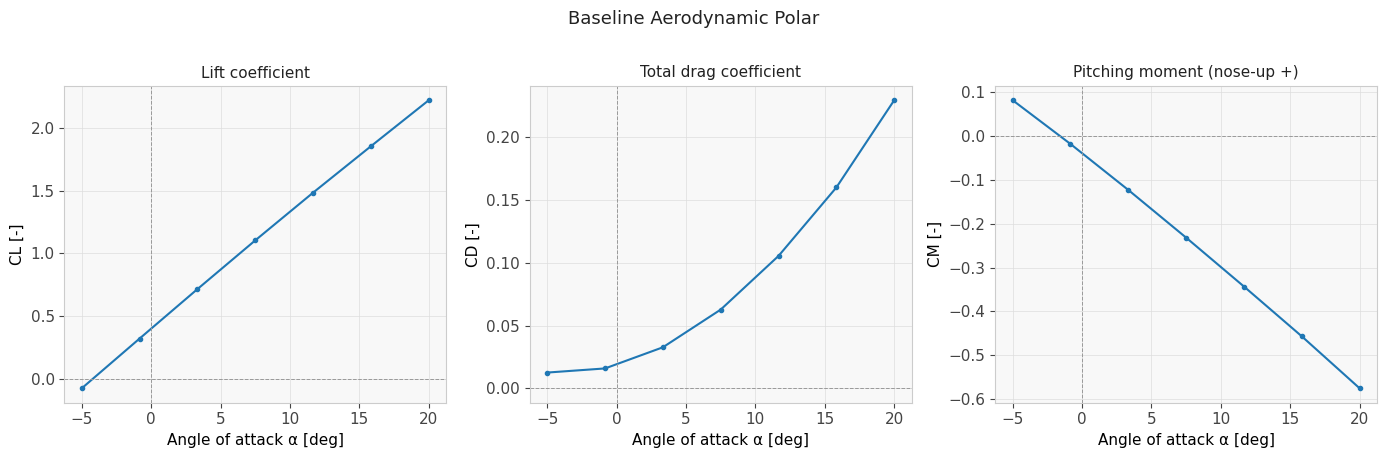

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
from vspopt import plot_polar, plot_drag_polar, plot_ld_ratio

fig = plot_polar(baseline, title="Baseline Aerodynamic Polar", export_dir=EXPORT_DIR)
plt.show()

00:38:48 [INFO   ] vspopt.plotting — Figure saved: C:\Users\UtenteLocale\Desktop\OpenVspController-main\exports\drag_polar.png


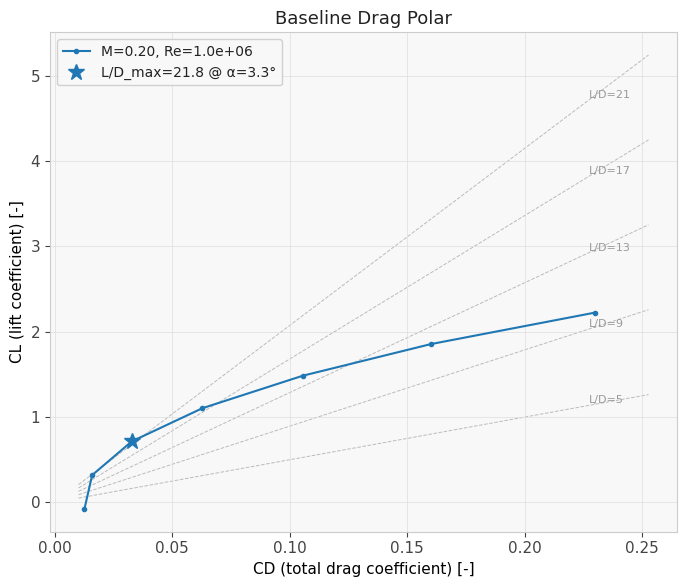

In [12]:
fig = plot_drag_polar(baseline, title="Baseline Drag Polar", export_dir=EXPORT_DIR)
plt.show()

00:38:50 [INFO   ] vspopt.plotting — Figure saved: C:\Users\UtenteLocale\Desktop\OpenVspController-main\exports\ld_ratio.png


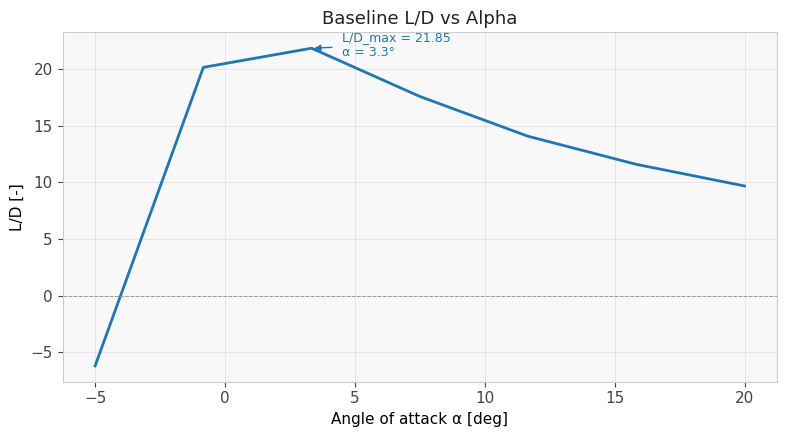

In [13]:
fig = plot_ld_ratio(baseline, title="Baseline L/D vs Alpha", export_dir=EXPORT_DIR)
plt.show()

---
## Section 5 — Parametric sweep

Vary one design variable at a time to understand its effect on aerodynamic performance.
This is a one-at-a-time (OAT) sensitivity analysis — not an optimisation, but a very
useful first look at which parameters matter most.

In [15]:
from vspopt import plot_sweep_grid

# ── Edit these to match your model ────────────────────────────────────────
SWEEP_COMPONENT = "WingGeom"       # geometry component name
SWEEP_PARAM     = "Span"       # parameter name
SWEEP_GROUP     = "XSec"   # parameter group
SWEEP_VALUES    = [10.0, 11.5, 13.0, 14.5, 16.0]  # values to try [m]
# ──────────────────────────────────────────────────────────────────────────

sweep_results = {}
original_value = model.wrapper.get_param(SWEEP_COMPONENT, SWEEP_PARAM, SWEEP_GROUP)

print(f"Sweeping {SWEEP_COMPONENT}/{SWEEP_PARAM}: {SWEEP_VALUES}")
for val in SWEEP_VALUES:
    model.wrapper.set_param(SWEEP_COMPONENT, SWEEP_PARAM, SWEEP_GROUP, val)
    r = model.wrapper.run_vspaero_sweep(**sweep_kwargs)
    sweep_results[val] = r
    print(f"  {SWEEP_PARAM}={val:.1f}  →  L/D_max={r.LD_max:.2f}")

# Restore original value
model.wrapper.set_param(SWEEP_COMPONENT, SWEEP_PARAM, SWEEP_GROUP, original_value)
print(f"\nRestored {SWEEP_PARAM} = {original_value:.4f}")


Sweeping WingGeom/Span: [10.0, 11.5, 13.0, 14.5, 16.0]
00:40:21 [INFO   ] vspopt.wrapper — Running VSPAEROSweep: alpha=[-5.0 deg, 20.0 deg] x 7 pts, M=0.20, Re=1.00e+06
00:40:21 [INFO   ] vspopt.wrapper — Computing VSPAERO Geometry (DegenGeom)...
00:40:25 [INFO   ] vspopt.wrapper — MassProp completed: extracted 41 result fields (including Total_CG).
[VSPAERO DEBUG] 'Alpha' -> Found directly.
[VSPAERO DEBUG] 'CL   ' -> Found directly.
[VSPAERO DEBUG] 'CDtot' -> Found directly.
[VSPAERO DEBUG] 'CDi  ' -> Found directly.
[VSPAERO DEBUG] 'CDo  ' -> Found directly.
[VSPAERO DEBUG] 'CDsff' -> Found directly.
[VSPAERO DEBUG] 'CMy  ' -> Found directly.
[VSPAERO DEBUG] 'CMx  ' -> Found directly.
[VSPAERO DEBUG] 'CMz  ' -> Found directly.
[VSPAERO DEBUG] 'CS   ' -> Found directly.
[VSPAERO DEBUG] 'LD   ' -> Found directly.
[VSPAERO DEBUG] 'E    ' -> Found directly.
[VSPAERO DEBUG] 'CFx  ' -> Found directly.
[VSPAERO DEBUG] 'CFy  ' -> Found directly.
[VSPAERO DEBUG] 'CFz  ' -> Found directly.
00:

In [16]:
print(model.wrapper.get_all_params('WingGeom'))

{'XForm/Abs_Or_Relitive_flag': 1.0, 'XForm/Last_Scale': 1.0, 'XForm/Origin': 0.0, 'XForm/Scale': 1.0, 'XForm/X_Location': 0.46, 'XForm/X_Rel_Location': 0.46, 'XForm/X_Rel_Rotation': 0.0, 'XForm/X_Rotation': 0.0, 'XForm/Y_Location': 0.0, 'XForm/Y_Rel_Location': 0.0, 'XForm/Y_Rel_Rotation': 3.0, 'XForm/Y_Rotation': 3.0, 'XForm/Z_Location': 0.853, 'XForm/Z_Rel_Location': 0.853, 'XForm/Z_Rel_Rotation': 0.0, 'XForm/Z_Rotation': 0.0, 'Sym/Sym_Ancestor': 1.0, 'Sym/Sym_Ancestor_Origin_Flag': 1.0, 'Sym/Sym_Axial_Flag': 0.0, 'Sym/Sym_Planar_Flag': 2.0, 'Sym/Sym_Rot_N': 2.0, 'Attach/Eta_Attach_Location': 0.0, 'Attach/L_01': 1.0, 'Attach/L_Attach_Location': 0.0, 'Attach/L_Attach_Location0Len': 0.0, 'Attach/M_Attach_Location': 0.5, 'Attach/N_Attach_Location': 0.5, 'Attach/R_01': 1.0, 'Attach/R_Attach_Location': 0.0, 'Attach/R_Attach_Location0N': 0.0, 'Attach/Rots_Attach_Flag': 0.0, 'Attach/S_Attach_Location': 0.5, 'Attach/T_Attach_Location': 0.5, 'Attach/Trans_Attach_Flag': 0.0, 'Attach/U_01': 1.0,

00:41:16 [INFO   ] vspopt.plotting — [plot_sweep_grid] Plotting 5/5 results for LD vs alpha
00:41:17 [INFO   ] vspopt.plotting — Figure saved: C:\Users\UtenteLocale\Desktop\OpenVspController-main\exports\sweep_LD_vs_alpha.png


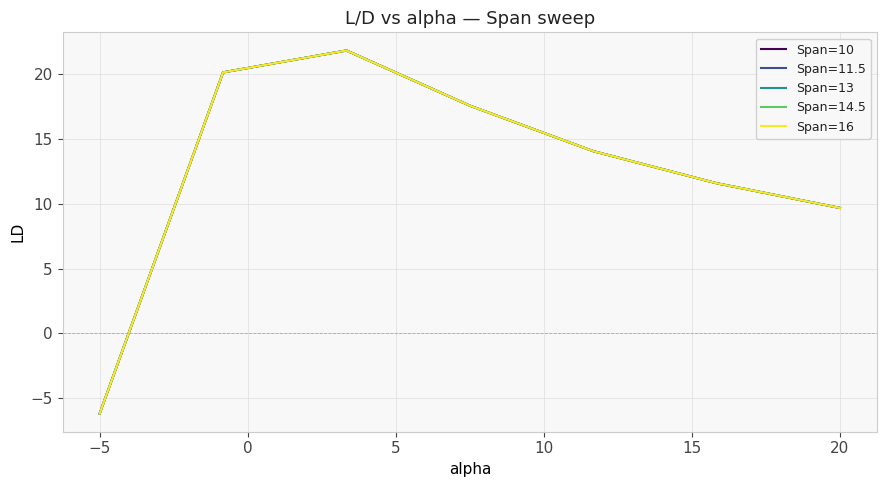

00:41:17 [INFO   ] vspopt.plotting — [plot_sweep_grid] Plotting 5/5 results for CL vs CD
00:41:17 [INFO   ] vspopt.plotting — Figure saved: C:\Users\UtenteLocale\Desktop\OpenVspController-main\exports\sweep_CL_vs_CD.png


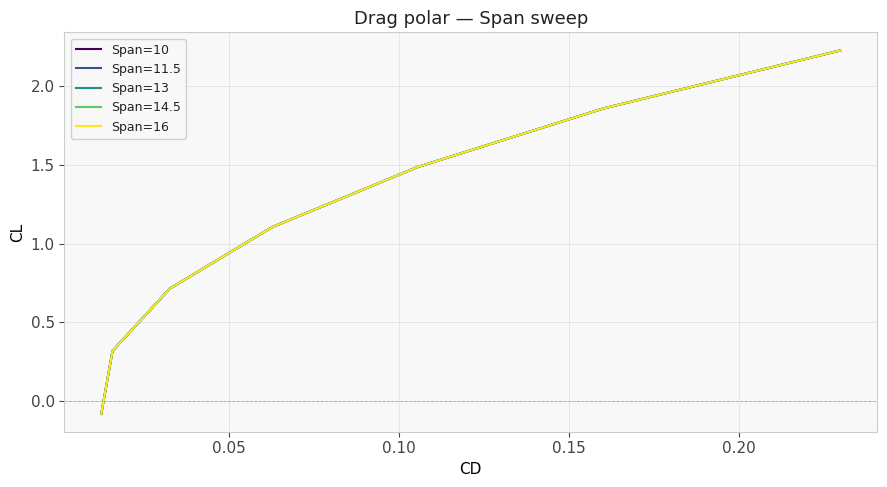

In [17]:
fig = plot_sweep_grid(
    sweep_results, x_key="alpha", y_key="LD",
    sweep_label=SWEEP_PARAM,
    title=f"L/D vs alpha — {SWEEP_PARAM} sweep",
    export_dir=EXPORT_DIR,
)
plt.show()

fig2 = plot_sweep_grid(
    sweep_results, x_key="CD", y_key="CL",
    sweep_label=SWEEP_PARAM,
    title=f"Drag polar — {SWEEP_PARAM} sweep",
    export_dir=EXPORT_DIR,
)
plt.show()

---
## Section 6 — Gradient-based optimisation (SLSQP)

### Mathematical background

**Sequential Least Squares Programming (SLSQP)** solves:

$$\min_{\mathbf{x}} f(\mathbf{x}) \quad \text{s.t.} \quad \mathbf{x}^{lb} \leq \mathbf{x} \leq \mathbf{x}^{ub}$$

At each iteration, the algorithm:
1. Approximates $f$ locally by a **quadratic model** $q(\mathbf{x})$.
2. Solves the quadratic subproblem to get a step direction $\mathbf{d}$.
3. Performs a **line search** along $\mathbf{d}$ to find a lower $f$.

Because $f$ is a black-box (not available analytically), gradients are
approximated by **forward finite differences**:
$$\frac{\partial f}{\partial x_i} \approx \frac{f(\mathbf{x} + \varepsilon \mathbf{e}_i) - f(\mathbf{x})}{\varepsilon}$$
This costs $n+1$ evaluations per iteration, where $n$ is the number of design variables.

**When to use:** When you have a good initial point and the landscape is smooth.  
**Limitation:** Can converge to a **local** minimum if the starting point is poor.

**Expected result:** Fast convergence (10–30 evaluations for $n \leq 5$), but the
optimum found depends strongly on the starting point.

### Design variables — configure here

In [18]:
from vspopt import DesignVariable, ObjectiveSpec, run_gradient_optimization
from vspopt import plot_optimization_history, plot_variable_sensitivity

# ── Define design variables ────────────────────────────────────────────────
# (geom_name, parm_name, group_name) must match exactly what
#  model.wrapper.get_all_params() returns for your model.
design_vars = [
    DesignVariable(
        label="Wing span",
        geom_name="Wing", parm_name="Span", group_name="WingGeom",
        lower=8.0, upper=18.0,
        initial=model.wing.span if model.wing else 12.0,
        units="m",
    ),
    DesignVariable(
        label="LE sweep",
        geom_name="Wing", parm_name="Sweep", group_name="XSec_1",
        lower=0.0, upper=45.0,
        initial=model.wing.sweep_le if model.wing else 15.0,
        units="deg",
    ),
    # Add more variables as needed:
    # DesignVariable("Taper", "Wing", "Taper", "XSec_1", 0.2, 1.0, 0.5),
]

# ── Define the objective ───────────────────────────────────────────────────
# Minimise −L/D_max (i.e. maximise L/D)
# Add constraint: CL at L/D_max must be >= 0.5 (ensure useful operating CL)
objective = ObjectiveSpec(
    metrics=[("LD_max", -1.0)],
    constraints=[("CL_at_LD", ">=", 0.5)],
)

print("Design variables:")
for dv in design_vars:
    print(f"  {dv}")
print(f"\nObjective: {objective.metrics}")
print(f"Constraints: {objective.constraints}")

ValueError: DesignVariable 'Wing span': initial=1.4 is outside bounds [8.0, 18.0].

In [19]:
print("Starting gradient-based optimisation...")
gradient_result = run_gradient_optimization(
    model.wrapper, design_vars, objective,
    sweep_kwargs=sweep_kwargs,
)
print(gradient_result)
print("\nBest parameters found:")
for dv, xv in zip(design_vars, gradient_result.best_x):
    print(f"  {dv.label} = {xv:.4f} {dv.units}")
print(f"\nPerformance at optimum:")
for k, v in gradient_result.best_metrics.items():
    print(f"  {k} = {v:.4f}")

Starting gradient-based optimisation...


NameError: name 'design_vars' is not defined

In [20]:
fig = plot_optimization_history(
    gradient_result,
    title="Gradient Optimisation Convergence",
    export_dir=EXPORT_DIR,
)
plt.show()

fig2 = plot_variable_sensitivity(
    gradient_result,
    title="Design Variable Sensitivity (Gradient)",
    export_dir=EXPORT_DIR,
)
plt.show()

NameError: name 'gradient_result' is not defined

---
## Section 7 — Bayesian optimisation (Optuna TPE)

### Mathematical background

**Bayesian optimisation** treats the objective function $f(\mathbf{x})$ as a **random
process** and builds a probabilistic surrogate model from observed data.

Optuna's **Tree-structured Parzen Estimator (TPE)** models two conditional densities:
- $\ell(\mathbf{x})$: density of good designs (those with $f < f^*$, the best observed value)
- $g(\mathbf{x})$: density of bad designs (those with $f \geq f^*$)

The next sample point is chosen by maximising the **Expected Improvement**:
$$\alpha_{EI}(\mathbf{x}) = \mathbb{E}\left[\max(f^* - f(\mathbf{x}), 0)\right] \propto \frac{\ell(\mathbf{x})}{g(\mathbf{x})}$$

This automatically **balances exploration** (sampling uncertain regions) and
**exploitation** (refining the best known region), using far fewer evaluations
than grid search or random search.

**Key advantage for VSPAERO:** Each call to VSPAERO takes several seconds.  Bayesian
optimisation typically finds a near-optimal design in 50–100 evaluations, whereas a
random search would require thousands.

**Expected result:** Better global coverage than SLSQP.  The convergence plot should
show rapid early improvement followed by slower refinement.

In [ ]:
from vspopt import run_bayesian_optimization

print(f"Starting Bayesian optimisation ({N_BAYESIAN_TRIALS} trials)...")
bayesian_result = run_bayesian_optimization(
    model.wrapper, design_vars, objective,
    sweep_kwargs=sweep_kwargs,
    n_trials=N_BAYESIAN_TRIALS,
    seed=RANDOM_SEED,
)
print(bayesian_result)
print("\nBest parameters found:")
for dv, xv in zip(design_vars, bayesian_result.best_x):
    print(f"  {dv.label} = {xv:.4f} {dv.units}")
print(f"\nPerformance at optimum:")
for k, v in bayesian_result.best_metrics.items():
    print(f"  {k} = {v:.4f}")

In [ ]:
fig = plot_optimization_history(
    bayesian_result,
    title="Bayesian Optimisation Convergence",
    export_dir=EXPORT_DIR,
)
plt.show()

fig2 = plot_variable_sensitivity(
    bayesian_result,
    title="Design Variable Sensitivity (Bayesian)",
    export_dir=EXPORT_DIR,
)
plt.show()

---
## Section 8 — Two-phase optimisation (recommended)

The two-phase strategy combines the strengths of both methods:

1. **Phase 1 — Bayesian (global):** Explores the design space broadly to find the
   basin of the global optimum.  Uses `n_bayesian_trials // 2` evaluations.
2. **Phase 2 — SLSQP (local):** Starting from the Bayesian best point, uses gradient
   information to precisely converge to the local optimum within that basin.

**Why this works:** The Bayesian phase identifies the *region* of the global optimum;
SLSQP then exploits the local smoothness of the objective to nail down the exact
minimum much faster than Bayesian alone could.

In [ ]:
from vspopt import run_two_phase_optimization

print("Starting two-phase optimisation...")
two_phase_bayesian, two_phase_slsqp = run_two_phase_optimization(
    model.wrapper, design_vars, objective,
    sweep_kwargs=sweep_kwargs,
    n_bayesian_trials=N_BAYESIAN_TRIALS // 2,
    seed=RANDOM_SEED,
)

print("\nPhase 1 (Bayesian):", two_phase_bayesian)
print("Phase 2 (SLSQP):  ", two_phase_slsqp)

---
## Section 9 — Comparison of all optimisation methods

In [ ]:
from vspopt import compare_results, plot_comparison_bar, plot_optimization_history

all_results = [gradient_result, bayesian_result, two_phase_slsqp]

comparison_df = compare_results(all_results)
print("\nOptimiser comparison:")
display(comparison_df)

In [ ]:
fig = plot_optimization_history(
    all_results,
    title="All Optimisers — Convergence Comparison",
    export_dir=EXPORT_DIR,
)
plt.show()

fig2 = plot_comparison_bar(
    all_results, metric="best_objective",
    title="Best objective value by method",
    export_dir=EXPORT_DIR,
)
plt.show()

---
## Section 10 — Optimised aircraft analysis

Re-run the full polar sweep at the best design found and compare against baseline.

In [ ]:
# Apply best parameters from two-phase result
best_params = two_phase_slsqp.best_params_dict()
print("Applying best design:")
for (geom, parm, group), val in best_params.items():
    print(f"  {geom}/{parm}/{group} = {val:.4f}")

model.wrapper.set_params(best_params)

print("\nRunning VSPAERO on optimised design...")
optimised = model.wrapper.run_vspaero_sweep(**sweep_kwargs)

# Compare
print(f"\n  Baseline   L/D_max = {baseline.LD_max:.2f}")
print(f"  Optimised  L/D_max = {optimised.LD_max:.2f}")
print(f"  Improvement: {(optimised.LD_max - baseline.LD_max)/baseline.LD_max*100:.1f}%")

In [ ]:
# Overlay baseline vs optimised on all polar plots
fig = plot_polar(
    [baseline, optimised],
    title="Baseline vs Optimised — Aerodynamic Polar",
    export_dir=EXPORT_DIR,
)
plt.show()

fig2 = plot_drag_polar(
    [baseline, optimised],
    title="Baseline vs Optimised — Drag Polar",
    export_dir=EXPORT_DIR,
)
plt.show()

---
## Section 11 — Export all figures

Export every figure in one call.  All `.png` files are written to `exports/`.

In [ ]:
from vspopt import export_all
export_all(optimised, all_results, EXPORT_DIR)
print("All figures saved to:", EXPORT_DIR.resolve())
import os
for f in sorted(EXPORT_DIR.glob("*.png")):
    print(f"  {f.name}")